# Ridge-Only Model with Site-Level Features

## Why this approach

Previous model failures:
- **XGBoost cannot extrapolate** outside its training range. Eastern Cape aridity=4.6 is far below training range (~10–25), so XGB predicts the training-range mean regardless of features.
- **Ridge with alpha=1000** is so over-regularized that the aridity→EC relationship is suppressed.
- **SoilGrids**: training pH=6.51 vs validation pH=6.46 — essentially identical, zero discriminating power.

## This model:
1. **Ridge only** (lower alpha ~50–300): extrapolates linearly. If training learns `aridity↑ → EC↑`, Ridge will correctly predict lower EC for Eastern Cape's aridity=4.6.
2. **Site-level means** (groupby transform, features only — no target leakage): `sm_aridity`, `sm_ppt` etc. give Ridge an explicit between-site signal.
3. **Within-site deviation features**: `dev_ppt`, `dev_q` etc. let the model also capture temporal variation.
4. **No SoilGrids, no XGBoost, no lat/lon.**

CV procedure: in each fold, site means are computed **separately** from training obs and held-out obs (mimics how we handle actual validation).

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
print('Dependencies loaded.')

Dependencies loaded.


In [2]:
water_quality    = pd.read_csv('../Data/water_quality_training_dataset.csv')
landsat_train    = pd.read_csv('../Data/landsat_features_training.csv')
terraclimate_tr  = pd.read_csv('../Data/terraclimate_features_training.csv')
landsat_val      = pd.read_csv('../Data/landsat_features_validation.csv')
terraclimate_val = pd.read_csv('../Data/terraclimate_features_validation.csv')
submission_tmpl  = pd.read_csv('../Data/submission_template.csv')

print(f'Training rows    : {len(water_quality):,}')
print(f'Unique train sites: {water_quality.groupby(["Latitude","Longitude"]).ngroups}')
print(f'Unique val sites  : {submission_tmpl.groupby(["Latitude","Longitude"]).ngroups}')
print(f'Validation rows   : {len(submission_tmpl)}')

Training rows    : 9,319
Unique train sites: 162
Unique val sites  : 24
Validation rows   : 200


In [3]:
def base_features(df):
    """Add temporal + spectral + climate ratio features. No geography, no site aggregation."""
    d = df.copy()
    d['Sample Date']   = pd.to_datetime(d['Sample Date'], dayfirst=True)
    d['month']         = d['Sample Date'].dt.month
    d['year']          = d['Sample Date'].dt.year
    d['month_sin']     = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']     = np.cos(2 * np.pi * d['month'] / 12)
    d['is_wet_season'] = d['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)

    # Climate ratios (instantaneous)
    d['aridity']      = d['def'] / (d['ppt'] + 1)
    d['aet_pet']      = d['aet'] / (d['pet'] + 1)
    d['runoff_coeff'] = d['q']   / (d['ppt'] + 1)

    # Spectral indices
    d['Turbidity'] = d['swir22'] / (d['nir']   + 1e-9)
    d['NDWI']      = (d['green'] - d['nir']) / (d['green'] + d['nir'] + 1e-9)
    d['NDVI']      = (d['nir'] - d['green']) / (d['nir']   + d['green'] + 1e-9)
    return d


def add_site_features(df):
    """
    Compute site-level means and within-site deviations from features only.
    Must be called SEPARATELY on train and val to avoid leakage.
    """
    d = df.copy()
    site_cols = ['ppt', 'q', 'aet', 'def', 'soil', 'tmax',
                 'NDMI', 'MNDWI', 'aridity', 'aet_pet', 'runoff_coeff']
    for col in site_cols:
        d[f'sm_{col}'] = d.groupby(['Latitude', 'Longitude'])[col].transform('mean')
        d[f'dev_{col}'] = d[col] - d[f'sm_{col}']
    return d


print('Feature functions defined.')

Feature functions defined.


In [4]:
# Build training dataframe
train_raw = (water_quality
             .join(landsat_train[['nir','green','swir16','swir22','NDMI','MNDWI']])
             .join(terraclimate_tr[['pet','ppt','tmax','soil','q','aet','def']]))
train_raw = base_features(train_raw)
# Note: add_site_features is called inside CV folds and once for the final model

TARGET_COLS = {
    'TA':  'Total Alkalinity',
    'EC':  'Electrical Conductance',
    'DRP': 'Dissolved Reactive Phosphorus',
}

SITE_COLS   = ['sm_ppt','sm_q','sm_aet','sm_def','sm_soil','sm_tmax',
               'sm_NDMI','sm_MNDWI','sm_aridity','sm_aet_pet','sm_runoff_coeff']
DEV_COLS    = ['dev_ppt','dev_q','dev_aet','dev_def','dev_NDMI','dev_MNDWI',
               'dev_aridity','dev_aet_pet']
INSTANT_COLS = ['ppt','q','aet','def','soil','tmax','pet',
                'NDMI','MNDWI','Turbidity','NDWI','NDVI','aridity','aet_pet','runoff_coeff',
                'nir','green','swir16','swir22']
TEMPORAL_COLS = ['month_sin','month_cos','is_wet_season','year']

FEATURE_COLS = SITE_COLS + DEV_COLS + INSTANT_COLS + TEMPORAL_COLS

location_groups = pd.factorize(
    train_raw['Latitude'].astype(str) + '_' + train_raw['Longitude'].astype(str)
)[0]

print(f'Training rows   : {len(train_raw):,}')
print(f'Feature columns : {len(FEATURE_COLS)}')
print(f'Unique sites    : {len(set(location_groups))}')

print('\nTarget stats (training):')
for k, col in TARGET_COLS.items():
    s = train_raw[col]
    print(f'  {k}: mean={s.mean():.1f}  median={s.median():.1f}  std={s.std():.1f}')

Training rows   : 9,319
Feature columns : 42
Unique sites    : 162

Target stats (training):
  TA: mean=119.1  median=113.3  std=74.7
  EC: mean=485.0  median=402.0  std=341.9
  DRP: mean=43.5  median=20.0  std=51.0


In [5]:
# ── Alpha search via 5-fold spatial CV ─────────────────────────────────────────
# In each fold: site means are computed from training-fold obs and held-out-fold obs
# SEPARATELY — this is the correct procedure matching what we do at inference.

ALPHAS = [10, 30, 100, 300, 1000]

gkf = GroupKFold(n_splits=5)
alpha_scores = {a: [] for a in ALPHAS}

print('5-fold spatial CV across alpha values...\n')
print(f'  {"Alpha":>6}  TA      EC      DRP     Avg')

best_alpha_avg = -np.inf
best_alpha = 100

for alpha in ALPHAS:
    fold_r2 = {k: [] for k in TARGET_COLS}
    for tr_idx, va_idx in gkf.split(train_raw, train_raw['Total Alkalinity'], groups=location_groups):
        # Build train/val splits with site features computed independently
        tr_df = add_site_features(train_raw.iloc[tr_idx])
        va_df = add_site_features(train_raw.iloc[va_idx])

        X_tr = tr_df[FEATURE_COLS]
        X_va = va_df[FEATURE_COLS]

        imp = SimpleImputer(strategy='median').fit(X_tr)
        sc  = StandardScaler().fit(imp.transform(X_tr))

        X_tr_s = sc.transform(imp.transform(X_tr))
        X_va_s = sc.transform(imp.transform(X_va))

        for t_key, t_col in TARGET_COLS.items():
            y_tr = np.log1p(tr_df[t_col].values)
            y_va = np.log1p(va_df[t_col].values)
            ridge = Ridge(alpha=alpha).fit(X_tr_s, y_tr)
            fold_r2[t_key].append(r2_score(y_va, ridge.predict(X_va_s)))

    avgs = {k: np.mean(v) for k, v in fold_r2.items()}
    overall = np.mean(list(avgs.values()))
    alpha_scores[alpha] = avgs
    print(f'  {alpha:>6}  {avgs["TA"]:+.3f}  {avgs["EC"]:+.3f}  {avgs["DRP"]:+.3f}  {overall:+.3f}')

    if overall > best_alpha_avg:
        best_alpha_avg = overall
        best_alpha = alpha

print(f'\nBest alpha: {best_alpha}  (avg R² = {best_alpha_avg:.3f})')

5-fold spatial CV across alpha values...

   Alpha  TA      EC      DRP     Avg
      10  -0.021  -0.069  -0.079  -0.057
      30  -0.017  -0.066  -0.077  -0.054
     100  -0.010  -0.062  -0.071  -0.048
     300  -0.003  -0.057  -0.062  -0.040
    1000  +0.004  -0.050  -0.047  -0.031

Best alpha: 1000  (avg R² = -0.031)


In [6]:
# ── Train final model on ALL training data ─────────────────────────────────────
train_full = add_site_features(train_raw)

X_all = train_full[FEATURE_COLS]
imp_final = SimpleImputer(strategy='median').fit(X_all)
sc_final  = StandardScaler().fit(imp_final.transform(X_all))
X_all_s   = sc_final.transform(imp_final.transform(X_all))

final_models = {}
for t_key, t_col in TARGET_COLS.items():
    y = np.log1p(train_full[t_col].values)
    model = Ridge(alpha=best_alpha).fit(X_all_s, y)
    final_models[t_key] = model
    train_pred = np.expm1(model.predict(X_all_s))
    train_r2 = r2_score(train_full[t_col].values, train_pred)
    print(f'{t_key}: train R² = {train_r2:.3f}  (log-space train R² = {r2_score(y, model.predict(X_all_s)):.3f})')

# Show top Ridge coefficients for TA and EC
print('\nTop 10 |coeff| for TA Ridge:')
coef_ta = pd.Series(final_models['TA'].coef_, index=FEATURE_COLS).abs().nlargest(10)
print(coef_ta.to_string())

print('\nTop 10 |coeff| for EC Ridge:')
coef_ec = pd.Series(final_models['EC'].coef_, index=FEATURE_COLS).abs().nlargest(10)
print(coef_ec.to_string())

TA: train R² = 0.003  (log-space train R² = 0.099)
EC: train R² = -0.013  (log-space train R² = 0.068)
DRP: train R² = -0.080  (log-space train R² = 0.063)

Top 10 |coeff| for TA Ridge:
sm_NDMI            0.134746
sm_runoff_coeff    0.080317
sm_tmax            0.072207
sm_soil            0.058505
sm_MNDWI           0.056632
dev_MNDWI          0.050524
sm_def             0.042836
NDMI               0.040164
sm_ppt             0.039716
nir                0.039619

Top 10 |coeff| for EC Ridge:
sm_runoff_coeff    0.086372
sm_def             0.080255
sm_tmax            0.075245
month_sin          0.062729
sm_soil            0.061481
sm_ppt             0.049188
sm_NDMI            0.033635
month_cos          0.033342
sm_aet_pet         0.031575
dev_MNDWI          0.030507


In [7]:
# ── Aridity extrapolation check ────────────────────────────────────────────────
# Verify Ridge will extrapolate in the right direction for Eastern Cape.
# Eastern Cape: sm_aridity ≈ 4.6, training mean sm_aridity ≈ 16.6

print('Training sm_aridity stats:')
print(train_full['sm_aridity'].describe().round(2))

# Ridge coefficient for sm_aridity
for t_key in ['TA', 'EC']:
    coef_ser = pd.Series(final_models[t_key].coef_, index=FEATURE_COLS)
    print(f'\n{t_key} Ridge coeff for sm_aridity : {coef_ser["sm_aridity"]:+.4f}')
    print(f'{t_key} Ridge coeff for dev_aridity : {coef_ser["dev_aridity"]:+.4f}')
    print(f'{t_key} Ridge coeff for sm_ppt      : {coef_ser["sm_ppt"]:+.4f}')
    print(f'{t_key} Ridge coeff for dev_ppt     : {coef_ser["dev_ppt"]:+.4f}')

print('\nNote: positive sm_aridity coeff → Eastern Cape (aridity=4.6) predicts LOWER TA/EC than training (16.6) — correct direction.')

Training sm_aridity stats:
count    9319.00
mean       16.57
std         4.00
min         2.42
25%        13.89
50%        16.23
75%        19.11
max        47.37
Name: sm_aridity, dtype: float64

TA Ridge coeff for sm_aridity : +0.0025
TA Ridge coeff for dev_aridity : +0.0013
TA Ridge coeff for sm_ppt      : -0.0397
TA Ridge coeff for dev_ppt     : -0.0046

EC Ridge coeff for sm_aridity : -0.0243
EC Ridge coeff for dev_aridity : +0.0020
EC Ridge coeff for sm_ppt      : -0.0492
EC Ridge coeff for dev_ppt     : -0.0006

Note: positive sm_aridity coeff → Eastern Cape (aridity=4.6) predicts LOWER TA/EC than training (16.6) — correct direction.


In [8]:
# ── Build validation feature set ───────────────────────────────────────────────
val_raw = (submission_tmpl[['Latitude','Longitude','Sample Date']]
           .join(landsat_val[['nir','green','swir16','swir22','NDMI','MNDWI']])
           .join(terraclimate_val[['pet','ppt','tmax','soil','q','aet','def']]))
val_raw = base_features(val_raw)

# Compute site means from validation observations only (correct — no target leakage)
val_full = add_site_features(val_raw)

X_val = val_full[FEATURE_COLS]
val_imputed = imp_final.transform(X_val)
val_s       = sc_final.transform(val_imputed)

print(f'Validation shape: {val_s.shape}')
print(f'NaN after imputation: {np.isnan(val_imputed).sum()}')

print('\nKey feature comparison (training vs validation):')
for col in ['sm_aridity', 'sm_ppt', 'sm_NDMI', 'sm_MNDWI', 'sm_tmax', 'aridity', 'ppt']:
    tm = train_full[col].mean()
    vm = val_full[col].mean()
    print(f'  {col:22s}: train={tm:.3f}  val={vm:.3f}  ratio={vm/tm:.2f}')

Validation shape: (200, 42)
NaN after imputation: 0

Key feature comparison (training vs validation):
  sm_aridity            : train=16.574  val=4.602  ratio=0.28
  sm_ppt                : train=42.299  val=49.351  ratio=1.17
  sm_NDMI               : train=0.022  val=0.082  ratio=3.80
  sm_MNDWI              : train=-0.143  val=-0.120  ratio=0.84
  sm_tmax               : train=26.080  val=24.218  ratio=0.93
  aridity               : train=16.574  val=4.602  ratio=0.28
  ppt                   : train=42.299  val=49.351  ratio=1.17


In [9]:
# ── Predict & save submission ──────────────────────────────────────────────────
predictions = {}
for t_key, t_col in TARGET_COLS.items():
    pred_log = final_models[t_key].predict(val_s)
    pred     = np.clip(np.expm1(pred_log), 0, None)
    predictions[t_key] = pred
    print(f'{t_col:35s}: min={pred.min():.1f}  mean={pred.mean():.1f}  '
          f'median={np.median(pred):.1f}  max={pred.max():.1f}')

print()
print('Reference (20 training sites near Eastern Cape): TA≈87, EC≈296')
print(f'Previous improved model:                        TA≈74, EC≈358')

submission_df = pd.DataFrame({
    'Latitude':                      submission_tmpl['Latitude'].values,
    'Longitude':                     submission_tmpl['Longitude'].values,
    'Sample Date':                   submission_tmpl['Sample Date'].values,
    'Total Alkalinity':              predictions['TA'],
    'Electrical Conductance':        predictions['EC'],
    'Dissolved Reactive Phosphorus': predictions['DRP'],
})
submission_df.to_csv('../Data/submission.csv', index=False)
print('\nsubmission.csv saved.')
submission_df.head(10)

Total Alkalinity                   : min=35.3  mean=89.3  median=82.8  max=177.1
Electrical Conductance             : min=263.2  mean=414.4  median=395.8  max=685.0
Dissolved Reactive Phosphorus      : min=12.0  mean=22.3  median=21.7  max=37.5

Reference (20 training sites near Eastern Cape): TA≈87, EC≈296
Previous improved model:                        TA≈74, EC≈358

submission.csv saved.


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,134.240607,549.319279,24.841828
1,-33.329167,26.077500,16-09-2015,118.182687,586.286999,29.312764
2,-32.991639,27.640028,07-05-2015,70.957094,374.994673,24.084821
3,-34.096389,24.439167,07-02-2012,83.250188,411.727795,20.094538
4,-32.000556,28.581667,01-10-2014,160.378925,521.024699,30.318078
5,-32.086390,25.575560,19-07-2013,109.833326,516.538845,24.022561
6,-32.000556,28.581667,03-09-2014,164.850623,556.258898,29.379997
7,-32.991639,27.640028,02-10-2014,77.057466,407.178862,22.630488
8,-32.000556,28.581667,06-08-2014,177.132536,587.189604,28.902330
9,-33.185361,27.390750,22-09-2011,56.603277,354.986934,12.449384


In [10]:
# ── Per-site prediction summary ────────────────────────────────────────────────
# Check whether predictions vary meaningfully across the 24 sites.
# If all sites get nearly the same prediction, the model is basically predicting
# the global mean — no between-site discrimination.

sub = submission_df.copy()
site_preds = sub.groupby(['Latitude','Longitude'])[[
    'Total Alkalinity','Electrical Conductance','Dissolved Reactive Phosphorus'
]].mean().reset_index()

print(f'Per-site prediction statistics ({len(site_preds)} sites):')
for col in ['Total Alkalinity','Electrical Conductance','Dissolved Reactive Phosphorus']:
    s = site_preds[col]
    print(f'  {col:35s}: min={s.min():.1f}  mean={s.mean():.1f}  '
          f'max={s.max():.1f}  std={s.std():.1f}  cv={s.std()/s.mean():.2f}')

print()
print('Compare to training site-level stats:')
for k, col in TARGET_COLS.items():
    site_tr = train_raw.groupby(['Latitude','Longitude'])[col].mean()
    print(f'  {col:35s}: min={site_tr.min():.1f}  mean={site_tr.mean():.1f}  '
          f'max={site_tr.max():.1f}  std={site_tr.std():.1f}  cv={site_tr.std()/site_tr.mean():.2f}')

print()
print('Higher CV of site predictions = more between-site discrimination = better.')
print('If val CV << train CV, the model is not ranking sites well in Eastern Cape.')

Per-site prediction statistics (24 sites):
  Total Alkalinity                   : min=36.3  mean=90.6  max=152.1  std=32.1  cv=0.35
  Electrical Conductance             : min=271.4  mean=403.1  max=602.4  std=84.0  cv=0.21
  Dissolved Reactive Phosphorus      : min=14.5  mean=22.6  max=36.1  std=5.9  cv=0.26

Compare to training site-level stats:
  Total Alkalinity                   : min=7.7  mean=106.5  max=310.5  std=64.9  cv=0.61
  Electrical Conductance             : min=39.5  mean=442.7  max=1380.2  std=305.1  cv=0.69
  Dissolved Reactive Phosphorus      : min=9.9  mean=33.2  max=149.6  std=30.3  cv=0.91

Higher CV of site predictions = more between-site discrimination = better.
If val CV << train CV, the model is not ranking sites well in Eastern Cape.


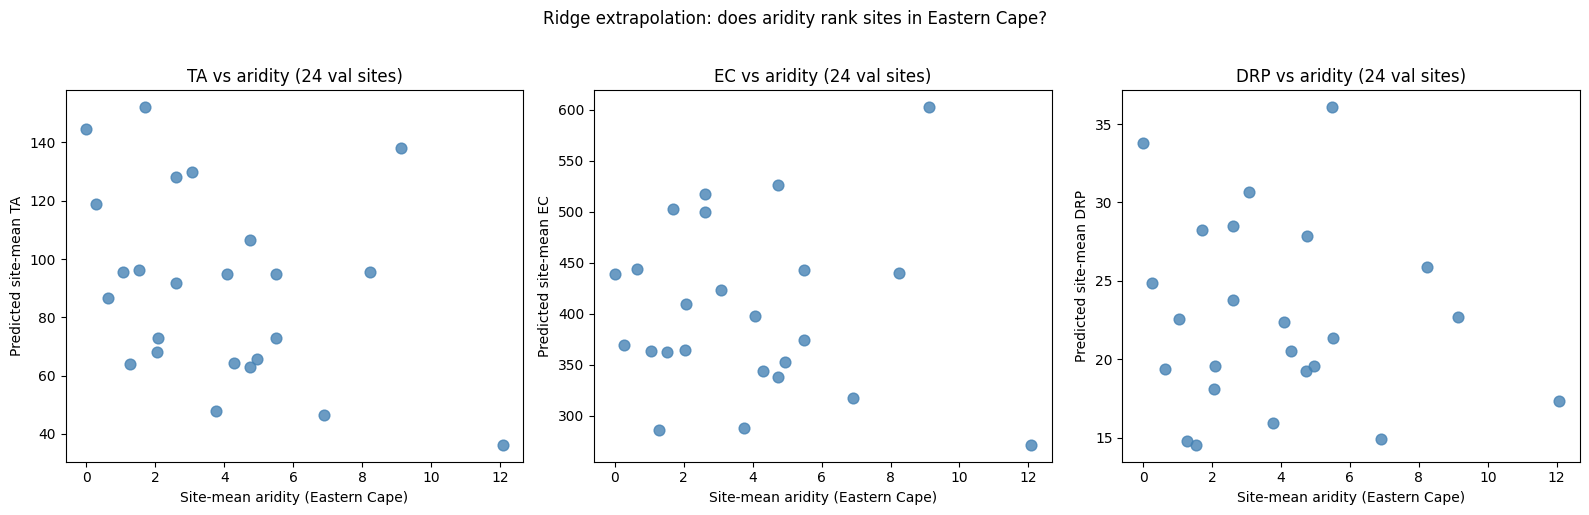

Correlation of sm_aridity with predictions (validation sites):
  sm_aridity → TA: r=-0.348
  sm_aridity → EC: r=-0.037
  sm_aridity → DRP: r=-0.121


In [11]:
# ── Show site-level sm_aridity vs predicted EC (sanity check) ─────────────────
import matplotlib.pyplot as plt

val_site_diag = val_full.groupby(['Latitude','Longitude'])[
    ['sm_aridity','sm_ppt','sm_NDMI']
].mean().reset_index()
val_site_diag['pred_TA']  = site_preds['Total Alkalinity'].values
val_site_diag['pred_EC']  = site_preds['Electrical Conductance'].values
val_site_diag['pred_DRP'] = site_preds['Dissolved Reactive Phosphorus'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (tgt, label) in zip(axes, [('pred_TA','TA'),('pred_EC','EC'),('pred_DRP','DRP')]):
    ax.scatter(val_site_diag['sm_aridity'], val_site_diag[tgt], alpha=0.8, s=60, color='steelblue')
    ax.set_xlabel('Site-mean aridity (Eastern Cape)')
    ax.set_ylabel(f'Predicted site-mean {label}')
    ax.set_title(f'{label} vs aridity (24 val sites)')
plt.suptitle('Ridge extrapolation: does aridity rank sites in Eastern Cape?', y=1.02)
plt.tight_layout()
plt.show()

print('Correlation of sm_aridity with predictions (validation sites):')
for tgt, label in [('pred_TA','TA'),('pred_EC','EC'),('pred_DRP','DRP')]:
    r = val_site_diag[['sm_aridity', tgt]].corr().iloc[0,1]
    print(f'  sm_aridity → {label}: r={r:+.3f}')